In [116]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

1: Data Loading & Understanding

In [117]:
df= pd.read_csv("winequality-red.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [118]:
df.shape

(1599, 12)

In [119]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [120]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [121]:
df["quality"] = df["quality"].apply(lambda x: 0 if x <= 5 else 1)


In [122]:
x = df.drop("quality", axis=1)  
y = df["quality"]  

In [123]:
df["quality"].unique()

array([0, 1])

In [124]:
print(y.value_counts())

quality
1    855
0    744
Name: count, dtype: int64


2: Data Preprocessing

In [125]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [126]:
df = df.drop(["density", "free sulfur dioxide"], axis=1)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,34.0,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,67.0,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,54.0,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,60.0,3.16,0.58,9.8,1
4,7.4,0.700,0.00,1.9,0.076,34.0,3.51,0.56,9.4,0
...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,44.0,3.45,0.58,10.5,0
1595,5.9,0.550,0.10,2.2,0.062,51.0,3.52,0.76,11.2,1
1596,6.3,0.510,0.13,2.3,0.076,40.0,3.42,0.75,11.0,1
1597,5.9,0.645,0.12,2.0,0.075,44.0,3.57,0.71,10.2,0


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   total sulfur dioxide  1599 non-null   float64
 6   pH                    1599 non-null   float64
 7   sulphates             1599 non-null   float64
 8   alcohol               1599 non-null   float64
 9   quality               1599 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 125.1 KB


3: Exploratory Data Analysis (EDA)

In [128]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,46.467792,3.311113,0.658149,10.422983,0.534709
std,1.741096,0.179060,0.194801,1.409928,0.047065,32.895324,0.154386,0.169507,1.065668,0.498950
min,4.600000,0.120000,0.000000,0.900000,0.012000,6.000000,2.740000,0.330000,8.400000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,22.000000,3.210000,0.550000,9.500000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,38.000000,3.310000,0.620000,10.200000,1.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,62.000000,3.400000,0.730000,11.100000,1.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,289.000000,4.010000,2.000000,14.900000,1.000000


array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'total sulfur dioxide'}>],
       [<Axes: title={'center': 'pH'}>,
        <Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>],
       [<Axes: title={'center': 'quality'}>, <Axes: >, <Axes: >]],
      dtype=object)

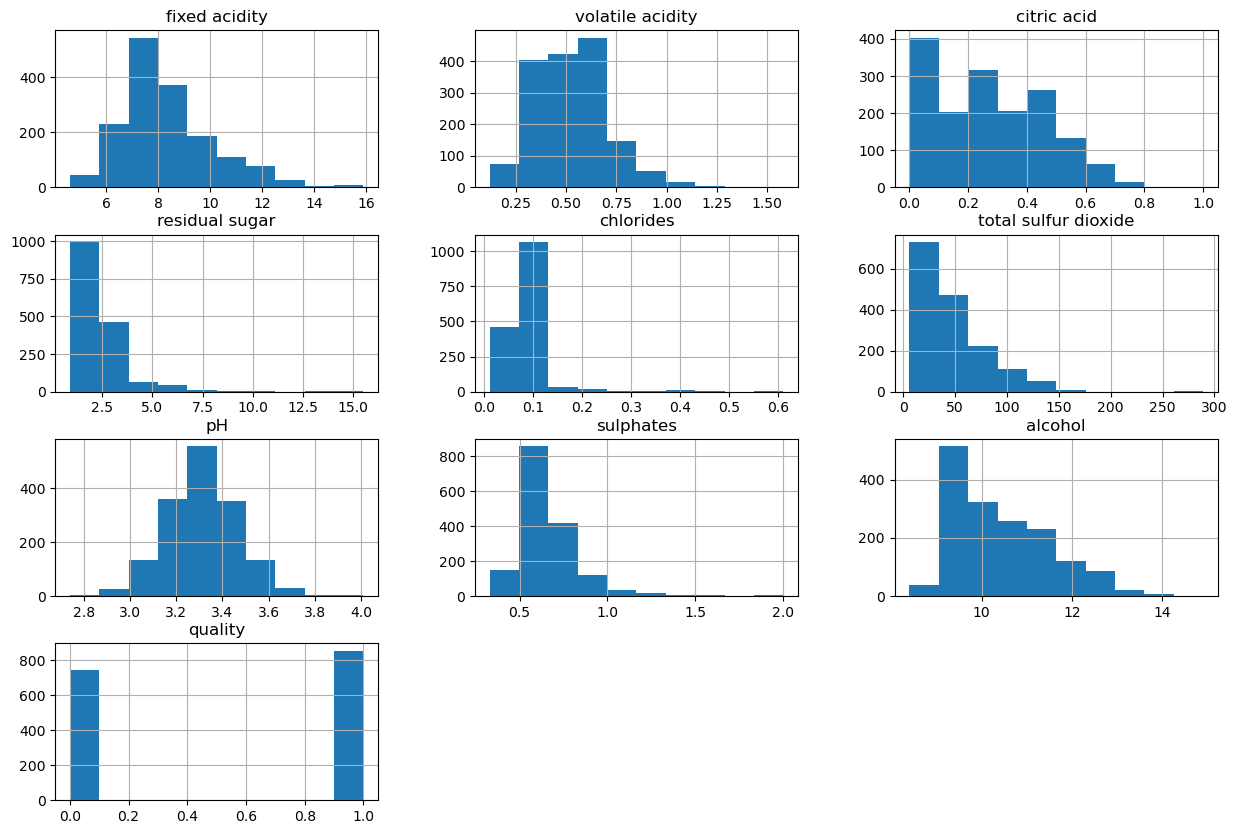

In [129]:
df.hist(figsize=(15,10))

<Axes: >

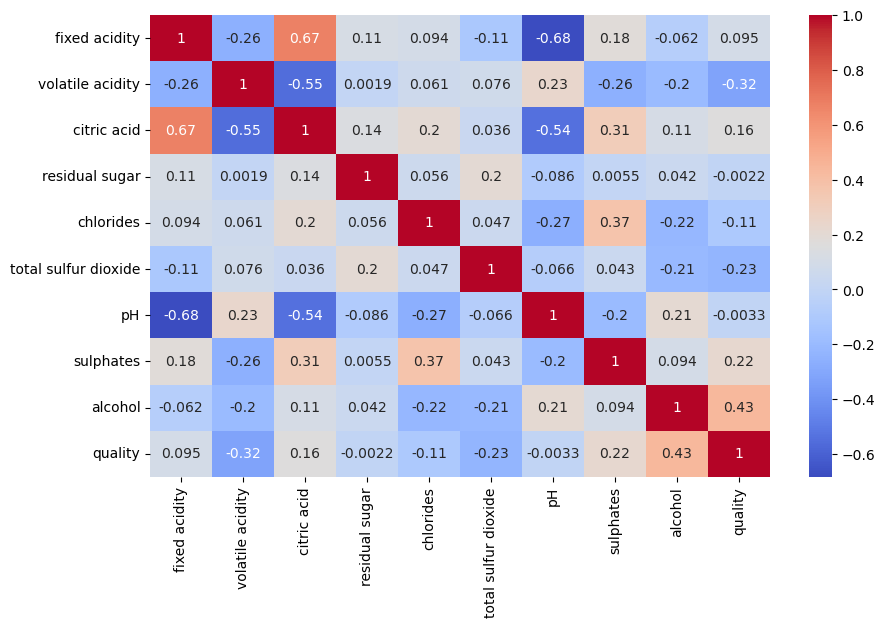

In [130]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True, cmap="coolwarm")

<Figure size 2000x1000 with 0 Axes>

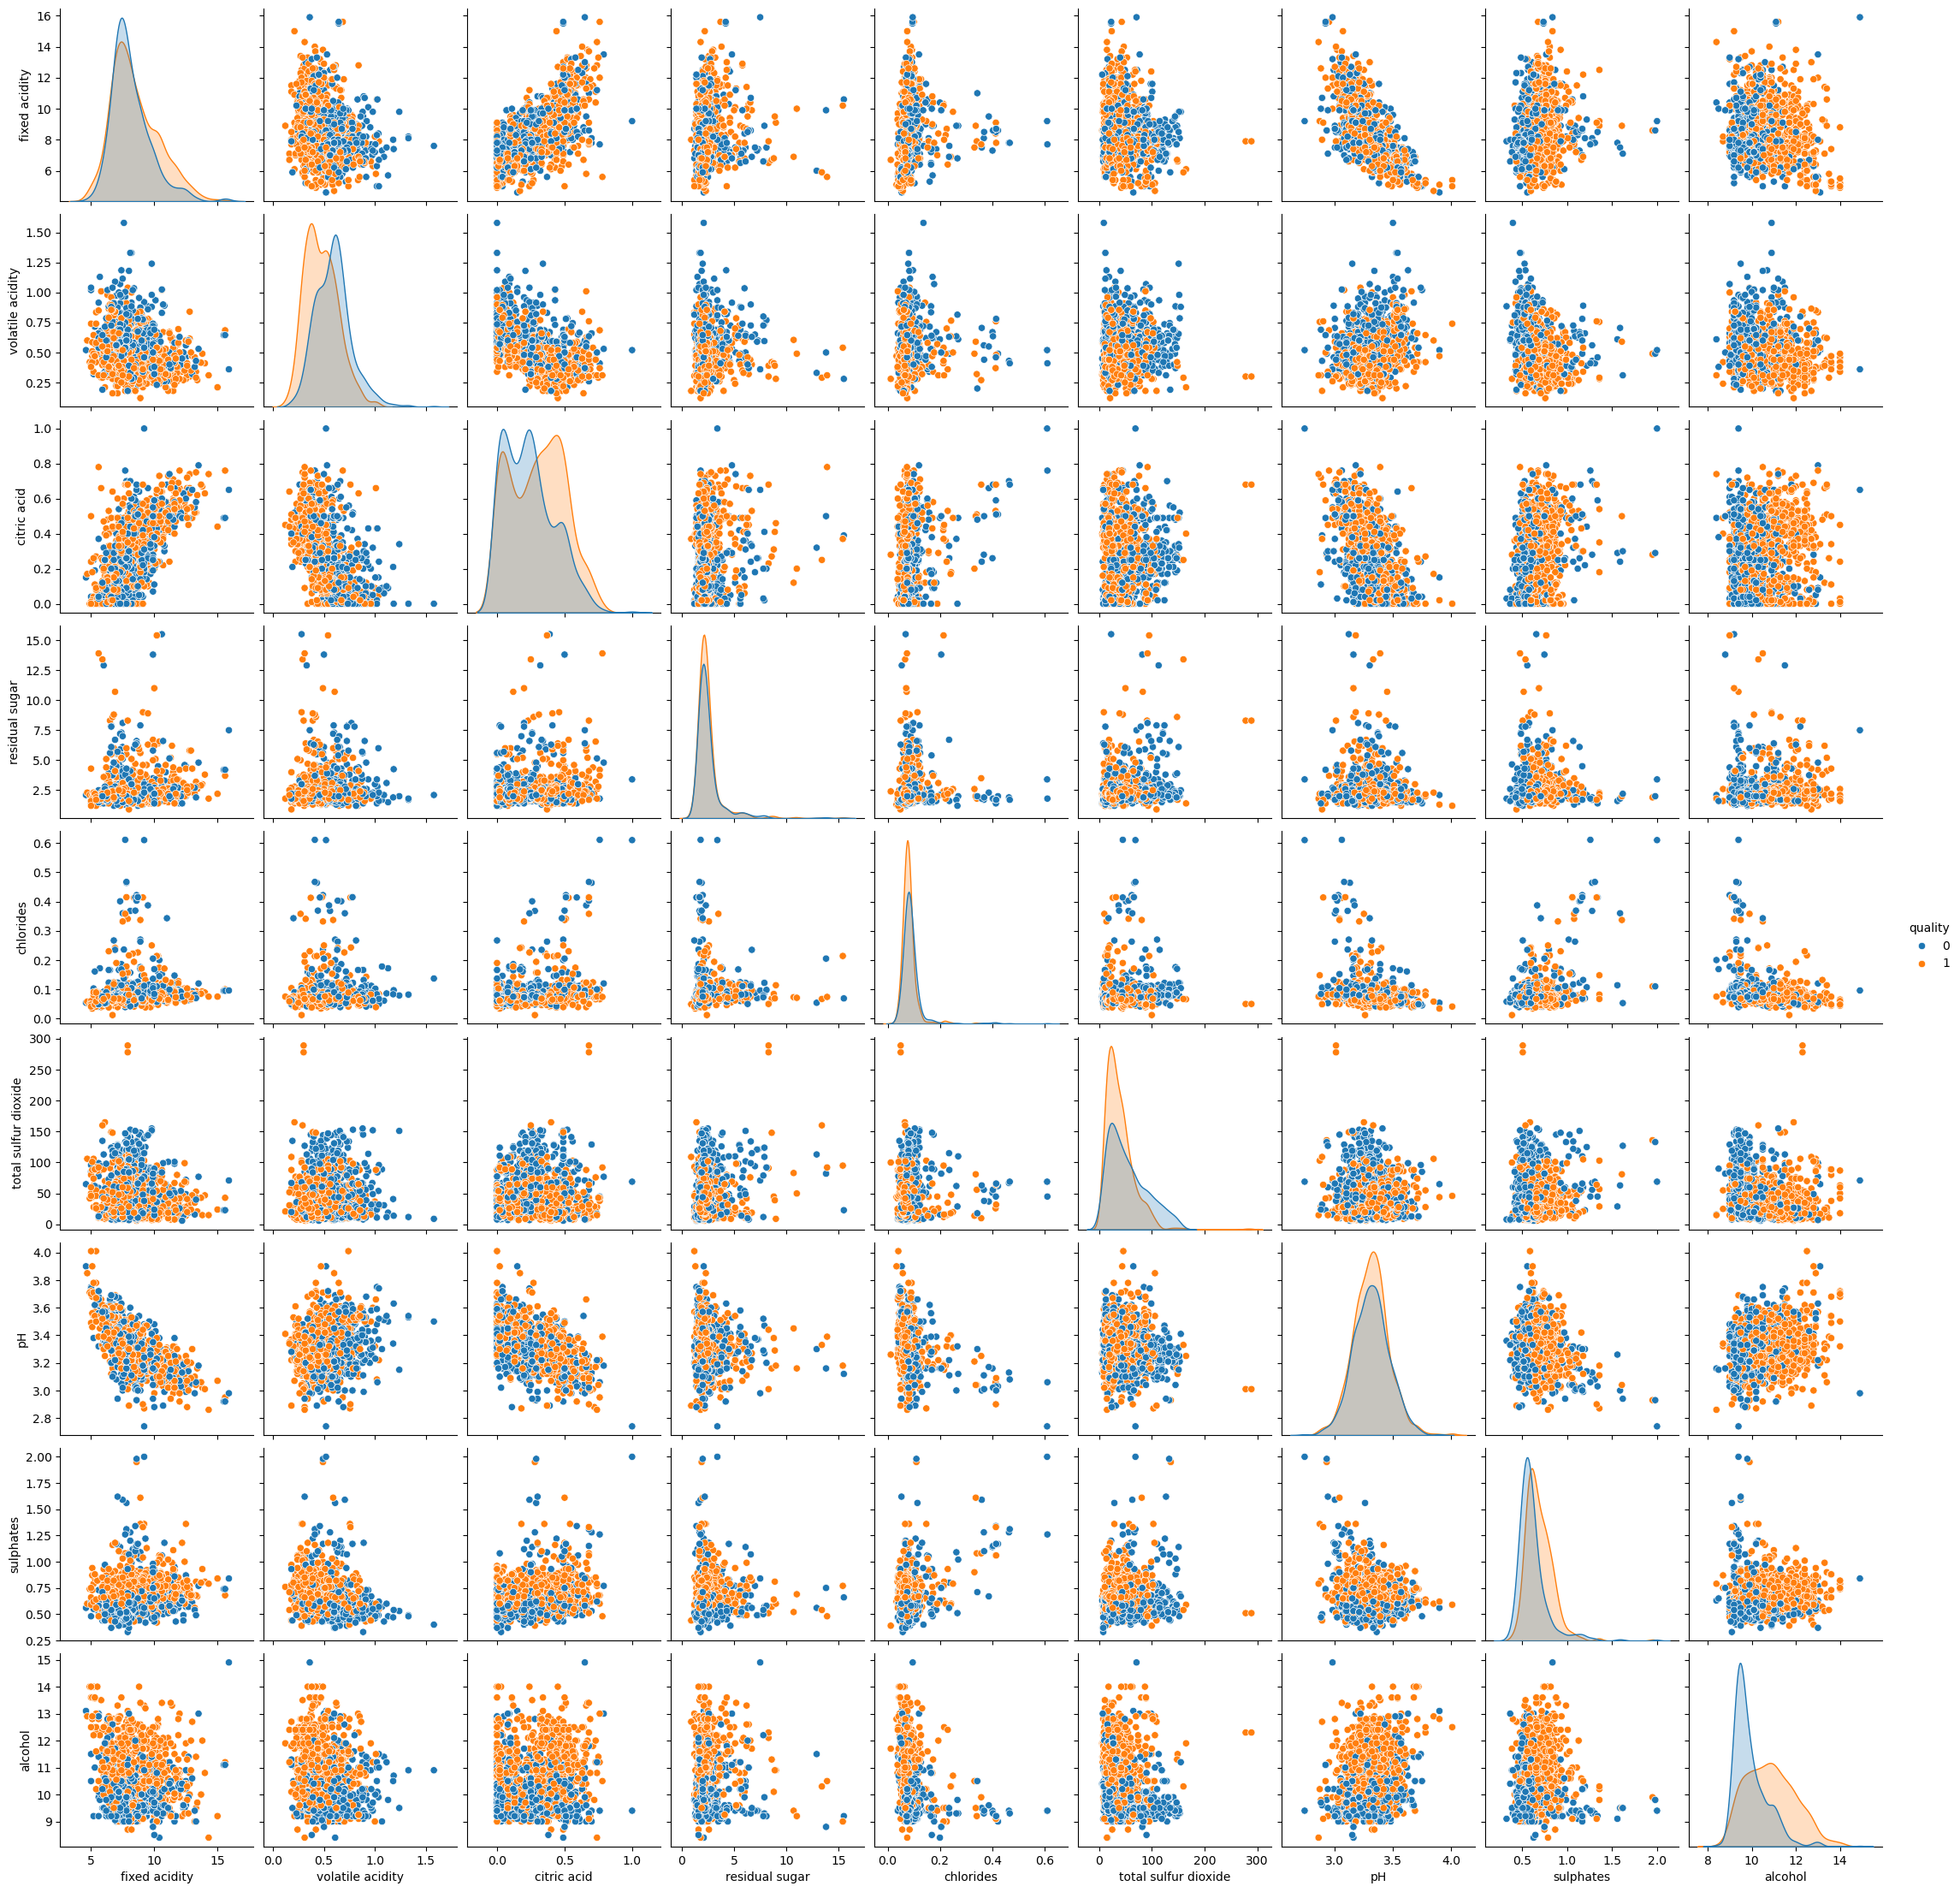

In [131]:
plt.figure(figsize=(20,10))
sns.pairplot(df, hue="quality")
plt.show()

4: Train-Test Split 

In [132]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=0)

In [133]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

5: Model Building 

In [150]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
gb = GradientBoostingClassifier(n_estimators=300,learning_rate=0.2,
    subsample=0.9,max_depth=4,min_samples_leaf=2,min_samples_split=4,random_state=0)

In [151]:
gb.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.2
,n_estimators,300
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


6: Model Evaluation

In [152]:
y_pred = gb.predict(x_test)

In [153]:
print('accuracy_score:',accuracy_score(y_test,y_pred))

accuracy_score: 0.809375


In [154]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.80      0.80       148
           1       0.83      0.81      0.82       172

    accuracy                           0.81       320
   macro avg       0.81      0.81      0.81       320
weighted avg       0.81      0.81      0.81       320



7: Prediction on New Data

In [155]:
import warnings
warnings.filterwarnings('ignore')
new_sample = np.array([[7.4, 0.7, 0.0, 1.9, 0.076,
                        11.0, 34.0, 0.9978, 3.51,
                        0.56, 9.4]])
new_sample_scaled = scaler.transform(new_sample)
predicted_label = gb.predict(new_sample_scaled)
print("Predicted Label for new sample:", predicted_label)

Predicted Label for new sample: [0]


In [156]:
expected_labels = [0]
comparison = list(zip(expected_labels, predicted_label))
print("Expected vs Predicted:", comparison)

Expected vs Predicted: [(0, np.int64(0))]


8: Hyperparameter Tuning 

In [157]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

n_estimators = [100, 200, 300]
learning_rates = [0.1, 0.05, 0.2]
max_depths = [3, 3, 5]

for i in range(len(n_estimators)):
    model = GradientBoostingClassifier(
        n_estimators=n_estimators[i],
        learning_rate=learning_rates[i],  
        max_depth=max_depths[i],
        random_state=0)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)

    print("n_estimators:", n_estimators[i])
    print("learning_rate:", learning_rates[i])
    print("max_depth:", max_depths[i])
    print("Accuracy:", accuracy)
    print("-" * 30)
        


n_estimators: 100
learning_rate: 0.1
max_depth: 3
Accuracy: 0.759375
------------------------------
n_estimators: 200
learning_rate: 0.05
max_depth: 3
Accuracy: 0.75
------------------------------
n_estimators: 300
learning_rate: 0.2
max_depth: 5
Accuracy: 0.8
------------------------------


9: Feature Importance Analysis 

In [172]:
imp = gb.feature_importances_
feature_imp = pd.DataFrame({'Feature': x.columns,
                'Importance': imp}).sort_values(by='Importance',
                ascending=False)
print(feature_imp)

                 Feature  Importance
10               alcohol    0.266688
9              sulphates    0.127010
6   total sulfur dioxide    0.118629
1       volatile acidity    0.108736
7                density    0.071007
4              chlorides    0.068573
8                     pH    0.058133
2            citric acid    0.050795
0          fixed acidity    0.046744
5    free sulfur dioxide    0.044803
3         residual sugar    0.038882


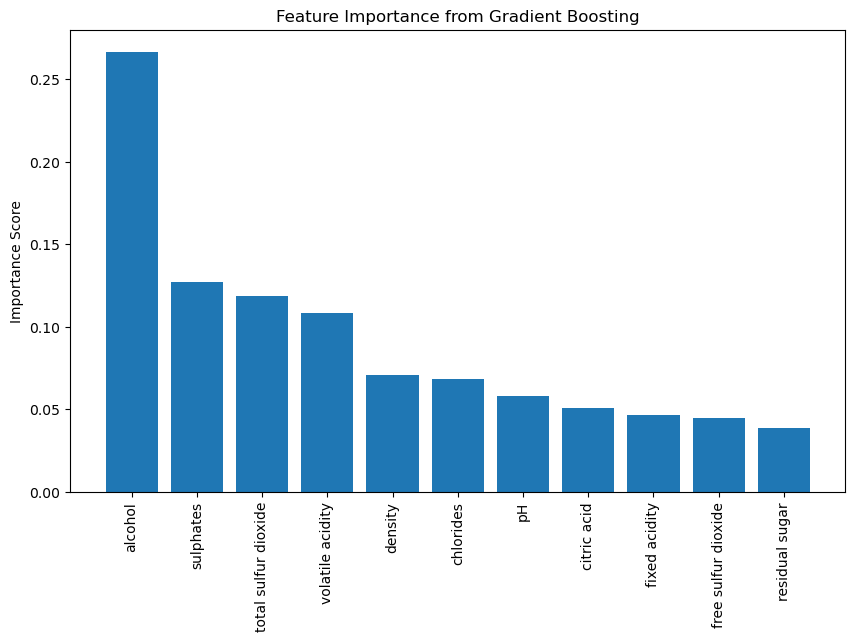

In [173]:
plt.figure(figsize=(10,6))
plt.bar(feature_imp['Feature'], feature_imp['Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importance from Gradient Boosting")
plt.ylabel("Importance Score")
plt.show()